#EMBEDDING + ATTENTION NN
##1. Import libraries
This section imports all required libraries for data processing, model building, and evaluation.

In [29]:
# Import libraries

import os, random, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Dense,
    Concatenate, Dropout, BatchNormalization, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

##2. Fix the random seed across all libraries.

Ensuring reproducibility

In [30]:
# Fix Random seed

seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("Seed fixed:", seed)

Seed fixed: 42


##3. Load Dataset

The dataset is loaded and column names are cleaned.

In [31]:
# Load data
df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df.columns = df.columns.str.strip()

target = "Conversion"

# Remove leakage
df = df.drop(columns=["CustomerID", "ConversionRate"], errors="ignore")

##4. Select significant features
Only the 10 statistically significant variables (p < 0.05) are retained, improving signal-to-noise ratio and reducing model complexity.
- CampaignType
- TimeOnSite
- EmailClicks
- AdSpend
- PagesPerVisit
- EmailOpens
- PreviousPurchases
- LoyaltyPoints
- ClickThroughRate
- WebsiteVisits

In [32]:
# Significant features
selected_features = [
    "CampaignType",
    "TimeOnSite",
    "EmailClicks",
    "AdSpend",
    "PagesPerVisit",
    "EmailOpens",
    "PreviousPurchases",
    "LoyaltyPoints",
    "ClickThroughRate",
    "WebsiteVisits"
]

df = df[selected_features + [target]]

categorical_cols = ["CampaignType"]
numerical_cols = [col for col in selected_features if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: ['CampaignType']
Numerical: ['TimeOnSite', 'EmailClicks', 'AdSpend', 'PagesPerVisit', 'EmailOpens', 'PreviousPurchases', 'LoyaltyPoints', 'ClickThroughRate', 'WebsiteVisits']


##5. Train / Validation / Test Split

Dataset is split into:

- 70% Training
- 15% Validation
- 15% Testing

In [33]:
# Train/Val/Test split (70/15/15)

X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n Distribution of y_test:")
print(y_test.value_counts())

print("\n Distribution of y_test (%):")
print(y_test.value_counts(normalize=True))

print("\nTrain:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


 Distribution of y_test:
Conversion
1    1052
0     148
Name: count, dtype: int64

 Distribution of y_test (%):
Conversion
1    0.876667
0    0.123333
Name: proportion, dtype: float64

Train: (5600, 10)
Val: (1200, 10)
Test: (1200, 10)


##6. Encode Categorical Variables

Objective: apply LabelEncoder to transform categorical values into numeric format

In [34]:
# Encode category
le = LabelEncoder()

X_train["CampaignType"] = le.fit_transform(X_train["CampaignType"])
X_val["CampaignType"] = le.transform(X_val["CampaignType"])
X_test["CampaignType"] = le.transform(X_test["CampaignType"])

##7. Scale Numerical Features

StandardScaler: normalize numerical features

In [35]:
# Scale numerical(no leakage)
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

##8. Class Weights
Objective: addressing class imbalance by
- Assigning higher penalty to minority class errors.
- Ensuring the model learns both classes effectively instead of being biased toward the majority class.

In [36]:
# Class weights (handle imbalance)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(4.046242774566474), 1: np.float64(0.5704971475142624)}


##9. Model Architecture
Key components
- Embedding layers for categorical variables
- Concatenation with numerical inputs
- Attention mechanism for feature weighting
- Fully connected layers (MLP)
- Dropout and Batch Normalization for regularization
- Sigmoid output layer for binary classification

In [37]:
# Build model

tf.keras.backend.clear_session()

# Categorical input (Embedding)
cat_input = Input(shape=(1,), name="CampaignType_input")
vocab_size = X_train["CampaignType"].nunique() + 1
embed_dim = min(8, vocab_size // 2 + 1)

cat_emb = Embedding(vocab_size, embed_dim)(cat_input)
cat_emb = Flatten()(cat_emb)

# Numerical input
num_input = Input(shape=(len(numerical_cols),), name="numerical_input")

# Concatenate
x = Concatenate()([cat_emb, num_input])

# Attention
attention_scores = Dense(32, activation="tanh")(x)
attention_weights = Dense(x.shape[-1], activation="softmax")(attention_scores)
x = Multiply()([x, attention_weights])

# MLP
x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)

# Output
output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=[cat_input, num_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ CampaignType_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 3)      │         15 │ CampaignType_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ numerical_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 12)        │        396 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 12)        │          0 │ concatenate[0][0… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12)        │         48 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,820 (14.92 KB)

 Trainable params: 3,796 (14.83 KB)

 Non-trainable params: 24 (96.00 B)

##10. Key components

Objectives:

- Mapping categorical features to corresponding input layers
- Grouping numerical features into a single input tensor
- Creating structured input dictionaries for the model
- Preparing separate inputs for training, validation, and testing datasets

In [38]:
# Prepare input
def prepare_inputs(X):
    return {
        "CampaignType_input": X["CampaignType"].values,
        "numerical_input": X[numerical_cols].values
    }

train_inputs = prepare_inputs(X_train)
val_inputs = prepare_inputs(X_val)
test_inputs = prepare_inputs(X_test)

##11. Model Training

- Training the model on prepared input data
- Validation on a separate dataset during training
- Early stopping based on validation loss
- Restoring best model weights to prevent overfitting
- Configuring epochs and batch size for optimization
- Tracking training history for performance analysis

In [39]:
# Training model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6327 - loss: 0.6499 - val_accuracy: 0.6758 - val_loss: 0.6575
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6814 - loss: 0.5979 - val_accuracy: 0.7600 - val_loss: 0.5820
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7312 - loss: 0.5647 - val_accuracy: 0.7283 - val_loss: 0.5702
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7539 - loss: 0.5428 - val_accuracy: 0.7392 - val_loss: 0.5609
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7773 - loss: 0.5291 - val_accuracy: 0.7442 - val_loss: 0.5606
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7841 - loss: 0.5281 - val_accuracy: 0.7700 - val_loss: 0.5339
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7961 - loss: 0.5150 - val_accuracy: 0.7825 - val_loss: 0.5316
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8039 - loss: 0.5150 - val_accuracy: 0.

##12. Confusion Matrix

Visualizes classification performance

- True Positive
- False Positive
- True Negative
- False Negative


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Confusion Matrix:
 [[ 93  55]
 [177 875]]

TN: 93
FP: 55
FN: 177
TP: 875


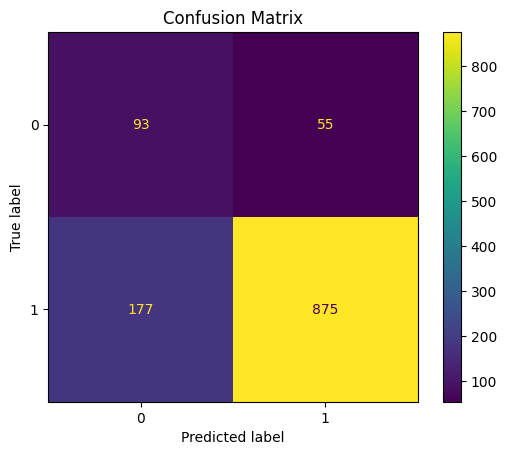

In [41]:
# Confusion Matrix
y_pred_prob = model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


##13. Model Evaluation
- AUC (Area Under Curve)
- F1-score

In [42]:
# Evaluating model
y_pred_prob = model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nAUC:", roc_auc_score(y_test, y_pred_prob))
print("F1:", f1_score(y_test, y_pred))


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

AUC: 0.7629675778440037
F1: 0.8829465186680121


##14. Metrics
- Accuracy
- Precision
- Recall

In [43]:
# Metrics
total = cm.sum()

print("\nMetrics:")
print(f"Accuracy: {(tp + tn) / total:.4f}")
print(f"Precision: {tp / (tp + fp):.4f}")
print(f"Recall: {tp / (tp + fn):.4f}")


Metrics:
Accuracy: 0.8067
Precision: 0.9409
Recall: 0.8317


##15. ROC Curve

- Shows trade-off between:

- False Positive Rate

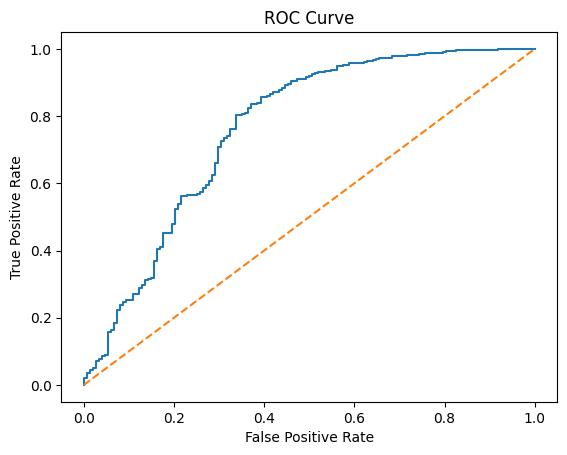

In [44]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##16. Training Curve

We plot:

- Training loss
- Validation loss to monior model performance and overfitting.

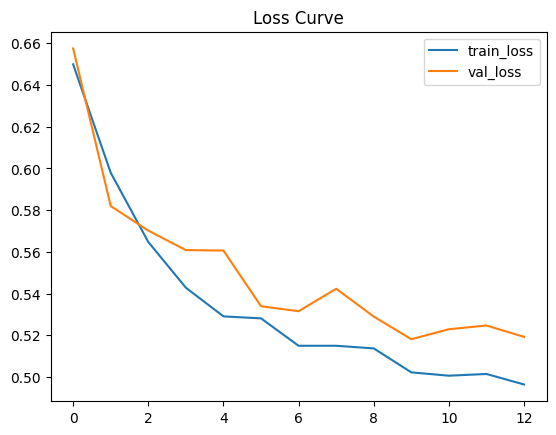

In [45]:
# Training Curve
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [47]:
model.save("../models/embedding _attention_deep_learning_model.h5")

print("Saved successfully!")

Saved successfully!
